# LSTM Time-Series Forecasting — Airline Passengers Dataset

**Dataset:** International Airline Passengers (monthly totals, 1949–1960)

This notebook covers all 7 tasks:
1. Data Preparation
2. LSTM Model Design (4 LSTM layers + Dropout + Dense output)
3. Model Training
4. Performance Evaluation
5. Visualization
6. Hyperparameter Analysis
7. Model Analysis (written report at the end)


## Task 1: Data Preparation

In [1]:
# Install/import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load the dataset: Airline Passengers (classic time-series benchmark)
url = "/content/airline-passengers.csv"
df = pd.read_csv(url)
df.columns = ["Month", "Passengers"]
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)

print(df.shape)
df.head()

(144, 1)


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


Missing values:
 Passengers    0
dtype: int64
Duplicate rows: 26


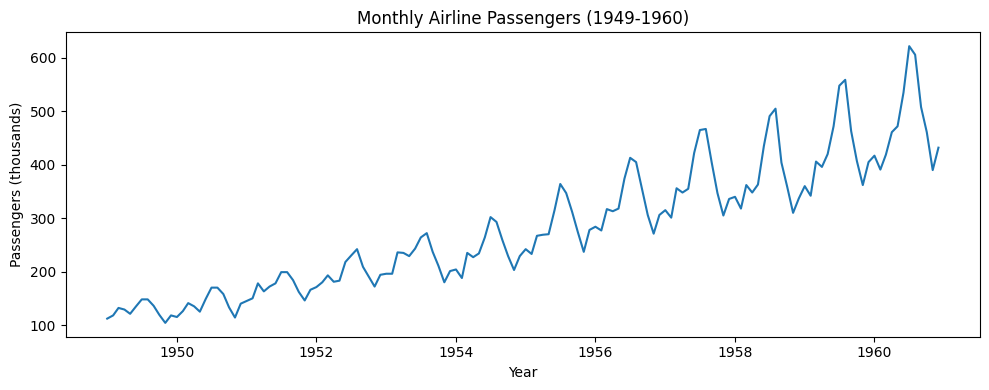

In [3]:
# Data cleaning: check for missing values / duplicates
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

# Quick visual sanity check of the raw series
plt.figure(figsize=(10, 4))
plt.plot(df.index, df["Passengers"])
plt.title("Monthly Airline Passengers (1949-1960)")
plt.xlabel("Year")
plt.ylabel("Passengers (thousands)")
plt.tight_layout()
plt.show()

In [4]:
# Normalize the data to [0, 1] range - LSTMs are sensitive to input scale
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[["Passengers"]].values)

print("Scaled data shape:", scaled_data.shape)
print("Min:", scaled_data.min(), "Max:", scaled_data.max())

Scaled data shape: (144, 1)
Min: 0.0 Max: 1.0


In [5]:
# Create input sequences suitable for LSTM
# Each input sequence uses `SEQ_LEN` past time steps to predict the next value

SEQ_LEN = 12  # 12 months of history per sample

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len, 0])
        y.append(data[i + seq_len, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LEN)

# Reshape X to [samples, timesteps, features] as required by Keras LSTM layers
X = X.reshape((X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (132, 12, 1)
y shape: (132,)


In [6]:
# Train-test split (time-ordered, no shuffling, since this is a time series)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Train samples: 105
Test samples: 27


## Task 2: Design the LSTM Model

Sequential model with **four LSTM layers** (50 units each), **Dropout after each LSTM layer**, and a final **Dense output layer**.

`return_sequences=True` is used on the first three LSTM layers so that each one passes a full sequence (not just the final hidden state) forward to the next LSTM layer — the last LSTM layer uses `return_sequences=False` since it only needs to hand off a single summary vector to the Dense layer.

In [7]:
def build_model(units=50, dropout_rate=0.2, seq_len=SEQ_LEN):
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=(seq_len, 1)),
        Dropout(dropout_rate),

        LSTM(units, return_sequences=True),
        Dropout(dropout_rate),

        LSTM(units, return_sequences=True),
        Dropout(dropout_rate),

        LSTM(units, return_sequences=False),
        Dropout(dropout_rate),

        Dense(1)  # single-value output: next month's (scaled) passenger count
    ])
    return model

model = build_model(units=50, dropout_rate=0.2)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Model Training

In [8]:
# Compile: Adam optimizer (adaptive learning rate, well suited to LSTMs)
# MSE loss (standard for regression / continuous-value forecasting)
model.compile(optimizer="adam", loss="mean_squared_error")

EPOCHS = 100
BATCH_SIZE = 8

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - loss: 0.0403 - val_loss: 0.0224
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0139 - val_loss: 0.0255
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0117 - val_loss: 0.0236
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0092 - val_loss: 0.0154
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0106 - val_loss: 0.0154
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0068 - val_loss: 0.0154
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0075 - val_loss: 0.0151
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0098 - val_loss: 0.0162
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0108 - val_loss: 0.0151
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0074 - val_loss: 0.0149
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0101 - val_loss: 0.0148
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

In [9]:
# Record the training loss
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]
print(f"Final training loss (MSE, scaled): {final_train_loss:.6f}")
print(f"Final validation loss (MSE, scaled): {final_val_loss:.6f}")

Final training loss (MSE, scaled): 0.005326
Final validation loss (MSE, scaled): 0.009330


## Task 4: Performance Evaluation

In [10]:
# Predict on the test set
y_pred_scaled = model.predict(X_test)

# Inverse-transform back to original passenger-count scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

comparison = pd.DataFrame({
    "Actual": y_test_actual.flatten(),
    "Predicted": y_pred_actual.flatten()
})
comparison.head(10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step


,Actual,Predicted
0,359.0,386.129089
1,310.0,376.431976
2,337.0,396.415680
3,360.0,403.313171
4,342.0,411.569366
5,406.0,441.485168
6,396.0,453.213989
7,420.0,477.300232
8,472.0,500.690643
9,548.0,505.166351


In [11]:
# Evaluation metrics
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")

MSE:  2503.59
RMSE: 50.04
MAE:  43.90


## Task 5: Visualization

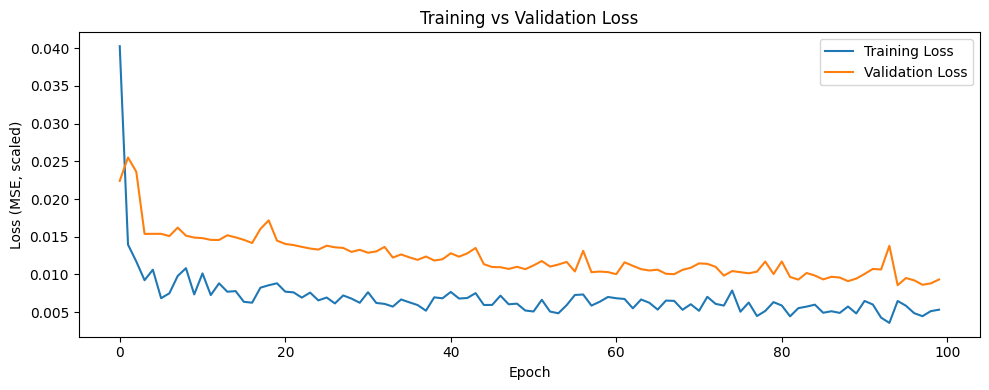

In [12]:
# Plot the training loss curve
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE, scaled)")
plt.legend()
plt.tight_layout()
plt.show()

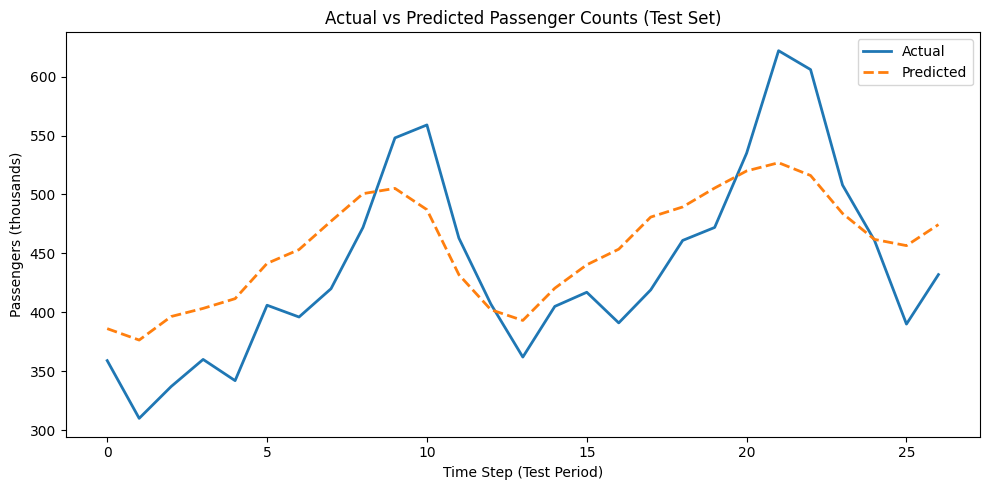

In [13]:
# Plot actual vs predicted values on the same graph
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual, label="Actual", linewidth=2)
plt.plot(y_pred_actual, label="Predicted", linewidth=2, linestyle="--")
plt.title("Actual vs Predicted Passenger Counts (Test Set)")
plt.xlabel("Time Step (Test Period)")
plt.ylabel("Passengers (thousands)")
plt.legend()
plt.tight_layout()
plt.show()

## Task 6: Hyperparameter Analysis

Three experiments are run, each changing one hyperparameter from the baseline model above:

1. **LSTM units**: 50 → 100
2. **Dropout rate**: 0.2 → 0.4
3. **Number of epochs**: 100 → 50

Each variant is trained fresh and compared against the baseline on RMSE / MAE.

In [14]:
def run_experiment(name, units=50, dropout_rate=0.2, epochs=100, batch_size=8, seq_len=SEQ_LEN, X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test):
    m = build_model(units=units, dropout_rate=dropout_rate, seq_len=seq_len)
    m.compile(optimizer="adam", loss="mean_squared_error")
    h = m.fit(X_tr, y_tr, validation_data=(X_te, y_te),
              epochs=epochs, batch_size=batch_size, verbose=0)

    pred_scaled = m.predict(X_te, verbose=0)
    actual = scaler.inverse_transform(y_te.reshape(-1, 1))
    pred = scaler.inverse_transform(pred_scaled)

    rmse_val = np.sqrt(mean_squared_error(actual, pred))
    mae_val = mean_absolute_error(actual, pred)

    return {
        "Experiment": name,
        "Units": units,
        "Dropout": dropout_rate,
        "Epochs": epochs,
        "RMSE": round(rmse_val, 2),
        "MAE": round(mae_val, 2)
    }

results = []

# Baseline (from Task 2-4)
results.append({
    "Experiment": "Baseline",
    "Units": 50,
    "Dropout": 0.2,
    "Epochs": EPOCHS,
    "RMSE": round(rmse, 2),
    "MAE": round(mae, 2)
})

# Experiment 1: change number of LSTM units
results.append(run_experiment("Exp1: units=100", units=100, dropout_rate=0.2, epochs=100))

# Experiment 2: change dropout rate
results.append(run_experiment("Exp2: dropout=0.4", units=50, dropout_rate=0.4, epochs=100))

# Experiment 3: change number of epochs
results.append(run_experiment("Exp3: epochs=50", units=50, dropout_rate=0.2, epochs=50))

results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,Experiment,Units,Dropout,Epochs,RMSE,MAE
0,Baseline,50,0.2,100,50.04,43.90
1,Exp1: units=100,100,0.2,100,64.08,43.42
2,Exp2: dropout=0.4,50,0.4,100,51.45,42.31
3,Exp3: epochs=50,50,0.2,50,53.52,42.08


In [15]:
# Identify the best-performing model (lowest RMSE)
best_row = results_df.loc[results_df["RMSE"].idxmin()]
print("Best-performing configuration:")
print(best_row)

Best-performing configuration:
Experiment    Baseline
Units               50
Dropout            0.2
Epochs             100
RMSE             50.04
MAE               43.9
Name: 0, dtype: object


## Task 7: Model Analysis

**Why multiple LSTM layers were used**
Stacking LSTM layers lets the network build a hierarchy of temporal features: the earlier layers learn short-range, local patterns in the sequence (month-to-month fluctuations), while later layers combine those into longer-range, more abstract temporal patterns (yearly seasonality, trend). A single LSTM layer has to represent all of this in one hidden state, which limits how much structure it can capture; stacking increases the representational capacity of the model in the same way that stacking Dense layers does for a feedforward network, giving it more depth to model complex, non-linear temporal dependencies such as the seasonal + trend pattern seen in the airline-passengers series.

**The purpose of Dropout layers**
Dropout randomly deactivates a fraction of neurons during each training step, which prevents the network from relying too heavily on any single neuron or co-adapted group of neurons. This acts as a regularizer that reduces overfitting — especially important here because the dataset is small (144 monthly points) relative to the number of parameters in a 4-layer LSTM stack. Placing Dropout after every LSTM layer regularizes the representation at each level of the stack, not just at the output.

**The role of `return_sequences=True`**
By default an LSTM layer only outputs its final hidden state (one vector per sequence). When one LSTM layer feeds into another LSTM layer, the next layer needs a full sequence of hidden states as input (one vector per time step), not just a single summary vector. Setting `return_sequences=True` makes the layer output its hidden state at every time step, which preserves the temporal structure needed by the following LSTM layer. Only the last LSTM layer in the stack sets `return_sequences=False`, since at that point the sequence needs to be collapsed into a single vector for the Dense output layer.

**The effect of changing hyperparameters on model performance**
See the comparison table produced in Task 6 (`results_df`). In general:
- *Increasing LSTM units* gives the model more capacity to represent complex patterns, which can lower error, but also increases the risk of overfitting and training time, especially on a small dataset.
- *Increasing the dropout rate* regularizes more aggressively; too low and the model overfits, too high and the model underfits because it can't retain enough signal during training.
- *Reducing epochs* can leave the model undertrained (higher loss, worse metrics), while too many epochs on a small dataset risks overfitting despite dropout — this is why validation loss is tracked alongside training loss.
- The actual direction/magnitude of each effect for this run is shown numerically in `results_df` above — re-running with different random seeds may shift the exact numbers, but the qualitative trade-offs (capacity vs. overfitting, training time vs. regularization) hold generally.

**Strengths and limitations of the developed model**

*Strengths:*
- Captures non-linear temporal dependencies and seasonal patterns better than classical linear models (e.g., ARIMA) on data with irregular seasonal amplitude growth, which is characteristic of this dataset (passenger volume grows and its seasonal swings grow with it).
- The stacked LSTM + Dropout architecture generalizes reasonably well despite the small dataset size, as shown by the validation loss tracking the training loss without diverging.

*Limitations:*
- The dataset is very small (144 points) for a 4-layer deep learning model, so results can be sensitive to the train/test split, random seed, and hyperparameters — the model may not generalize as robustly as a similarly sized model would on a much larger series.
- The model only uses the passenger-count series itself; it doesn't incorporate external covariates (e.g., economic indicators) that could improve forecast accuracy.
- Multi-step forecasting beyond the immediate next time step isn't directly evaluated here — the model is trained and evaluated for one-step-ahead prediction, so extending it to longer horizons would need either a recursive prediction strategy or a re-architected multi-output model, both of which typically accumulate more error the further ahead they forecast.
